# SHAP Explainability for Churn Predictions

This notebook explains the trained XGBoost model globally and locally. SHAP TreeExplainer is optimized for tree-based ensembles and provides feature-level attributions.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

pipeline = joblib.load("../models/churn_model.joblib")
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)
X = df.drop(columns=["Churn", "customerID"])


## 1. Transform the data used by XGBoost

In [2]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]
X_transformed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()
X_transformed = pd.DataFrame(X_transformed, columns=feature_names, index=X.index)
sample = X_transformed.sample(n=min(1000, len(X_transformed)), random_state=42)
print(sample.shape)


(1000, 46)


## 2. Global SHAP importance

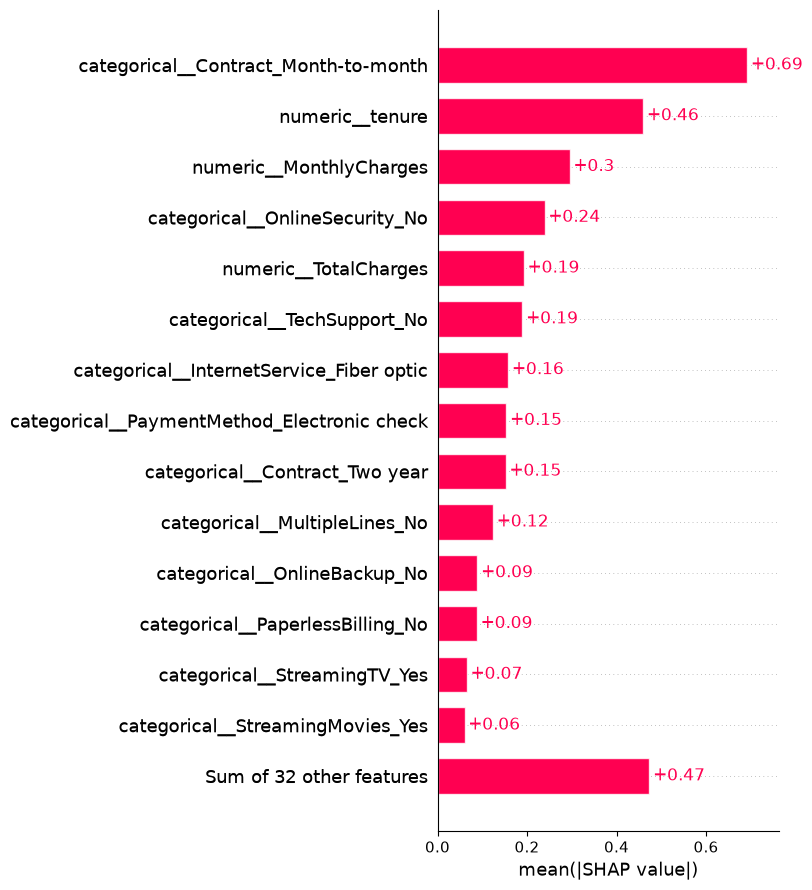

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()


## 3. SHAP beeswarm plot

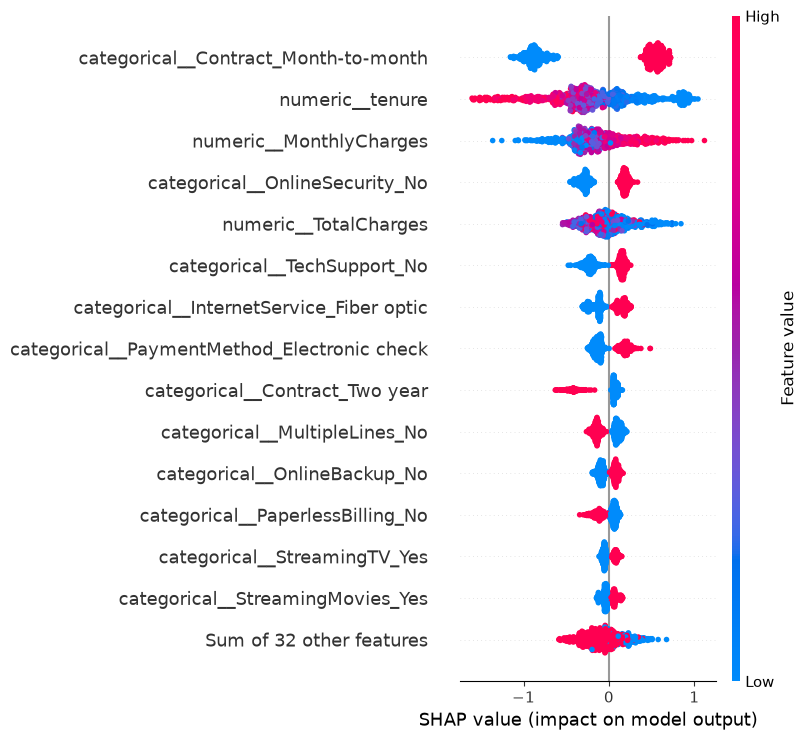

In [4]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()


## 4. Explain one customer

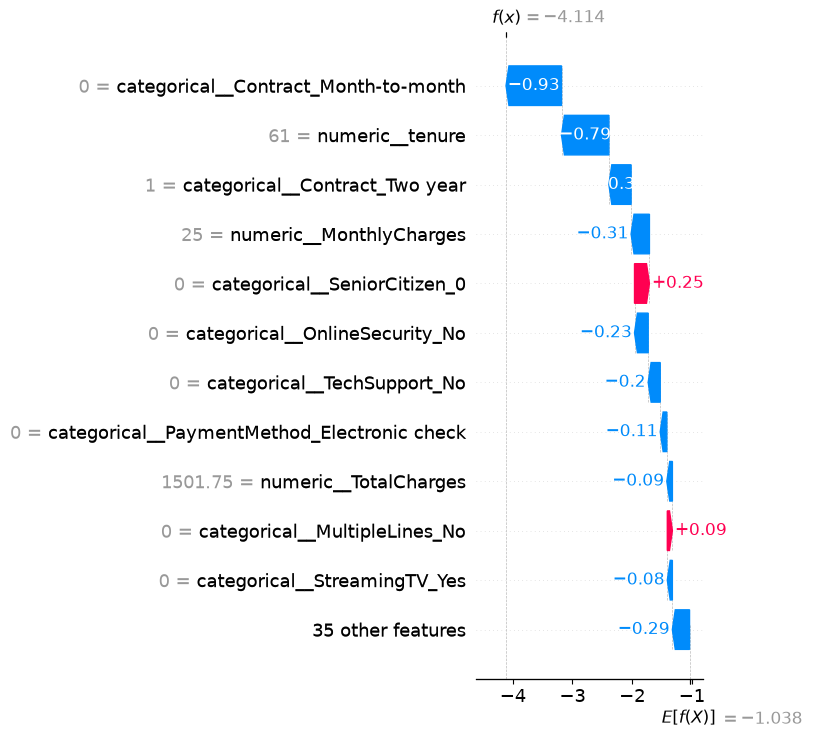

Positive SHAP values move the raw XGBoost output toward churn; negative values move it away from churn.


In [5]:
customer_explanation = explainer(sample.iloc[[0]])
shap.plots.waterfall(customer_explanation[0], max_display=12, show=False)
plt.tight_layout()
plt.show()
print("Positive SHAP values move the raw XGBoost output toward churn; negative values move it away from churn.")


## 5. Compact explanation table

In [6]:
values = customer_explanation.values[0]
explanation_table = pd.DataFrame({"feature": feature_names, "shap_value": values, "absolute_shap": np.abs(values)}).sort_values("absolute_shap", ascending=False).head(10)
explanation_table


,feature,shap_value,absolute_shap
34,categorical__Contract_Month-to-month,-0.929699,0.929699
43,numeric__tenure,-0.794054,0.794054
36,categorical__Contract_Two year,-0.372314,0.372314
44,numeric__MonthlyCharges,-0.307167,0.307167
2,categorical__SeniorCitizen_0,0.249803,0.249803
16,categorical__OnlineSecurity_No,-0.229253,0.229253
25,categorical__TechSupport_No,-0.201743,0.201743
41,categorical__PaymentMethod_Electronic check,-0.110369,0.110369
45,numeric__TotalCharges,-0.093435,0.093435
10,categorical__MultipleLines_No,0.085188,0.085188


## Interpretation note

SHAP describes the contribution of features to the trained model output. It does not prove that a feature is a causal reason for a customer leaving. Correlated variables and the model's learned relationships should be considered when presenting findings.